<a href="https://colab.research.google.com/github/deorebhumika06/ai-projects/blob/main/Netflix%20Data%20Analysis%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Netflix Data Analysis Project

## 📌 Objective
To analyze the Netflix dataset and extract meaningful insights about content distribution, trends, and audience targeting.

## 📂 Dataset Information
- Dataset Name: Netflix Dataset (netflex.csv)
- Features: Type, Title, Country, Release Year, Rating, Duration
- Tools Used: Python, Pandas, Matplotlib, Seaborn

In [ ]:
# IMPORT LIBRARIES

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Load Dataset

In [ ]:
df=pd.read_csv('/content/netflix1.csv.zip')
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


Data Cleaning Process

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [ ]:
df['show_id']=df['show_id'].astype(str).str.replace('s','').astype(int)

In [ ]:
df['date_added']=pd.to_datetime(df['date_added'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   int64         
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 686.8+ KB


In [ ]:
df.describe(include='object')

,type,title,director,country,rating,duration,listed_in
count,8790,8790,8790,8790,8790,8790,8790
unique,2,8787,4528,86,14,220,513
top,Movie,9-Feb,Not Given,United States,TV-MA,1 Season,"Dramas, International Movies"
freq,6126,2,2588,3240,3205,1791,362


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [ ]:
for col in df.columns:
  if df[col].nunique():
    print(col)
    print(df[col].value_counts())
    print('_'*50)

show_id
show_id
8786    1
1       1
3       1
6       1
14      1
       ..
941     1
940     1
13      1
939     1
10      1
Name: count, Length: 8790, dtype: int64
__________________________________________________
type
type
Movie      6126
TV Show    2664
Name: count, dtype: int64
__________________________________________________
title
title
9-Feb                                2
15-Aug                               2
22-Jul                               2
Septiembre, un llanto en silencio    1
Set Up                               1
                                    ..
Sei                                  1
Superlopez                           1
Oversize Cops                        1
Mirage                               1
The Highwaymen                       1
Name: count, Length: 8787, dtype: int64
__________________________________________________
director
director
Not Given                 2588
Rajiv Chilaka               20
Alastair Fothergill         18
Raúl Campos, Jan Sute

In [ ]:
for col in df.columns:
  print(col)
  print(df[col].unique())
  print('_'*50)


show_id
[   1    3    6 ... 8801 8784 8786]
__________________________________________________
type
['Movie' 'TV Show']
__________________________________________________
title
['Dick Johnson Is Dead' 'Ganglands' 'Midnight Mass' ...
 'Zindagi Gulzar Hai' 'Yoko' 'YOM']
__________________________________________________
director
['Kirsten Johnson' 'Julien Leclercq' 'Mike Flanagan' ... 'Majid Al Ansari'
 'Peter Hewitt' 'Mozez Singh']
__________________________________________________
country
['United States' 'France' 'Brazil' 'United Kingdom' 'India' 'Germany'
 'Pakistan' 'Not Given' 'China' 'South Africa' 'Japan' 'Nigeria' 'Spain'
 'Philippines' 'Australia' 'Argentina' 'Canada' 'Hong Kong' 'Italy'
 'New Zealand' 'Egypt' 'Colombia' 'Mexico' 'Belgium' 'Switzerland'
 'Taiwan' 'Bulgaria' 'Poland' 'South Korea' 'Saudi Arabia' 'Thailand'
 'Indonesia' 'Kuwait' 'Malaysia' 'Vietnam' 'Lebanon' 'Romania' 'Syria'
 'United Arab Emirates' 'Sweden' 'Mauritius' 'Austria' 'Turkey'
 'Czech Republic' 'Came

In [ ]:
import re

In [ ]:
def extract_duration(duration):
  duration_no=re.findall('[0-9]+',str(duration))
  if len(duration_no)>0:
    return int(duration_no[0])
  else:
    return None
df['duration']=df['duration'].apply(extract_duration)




In [ ]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90,Documentaries
1,3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act..."
2,6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1,"TV Dramas, TV Horror, TV Mysteries"
3,14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91,"Children & Family Movies, Comedies"
4,8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125,"Dramas, Independent Movies, International Movies"


**Visualization**

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


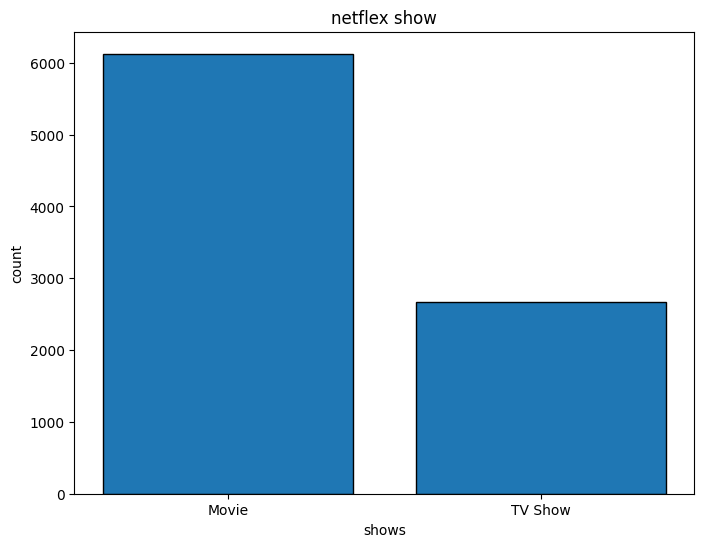

In [ ]:
typ_no=df['type'].value_counts()
print(typ_no)
plt.figure(figsize=(8,6))
plt.bar(typ_no.index,typ_no.values,edgecolor='k')
plt.title('netflex show')
plt.xlabel('shows')
plt.ylabel('count')
plt.show()

In [ ]:
#📊 Movies are more than TV Shows on Netflix.

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
                  ... 
Luxembourg           1
Senegal              1
Belarus              1
Puerto Rico          1
Cyprus               1
Name: count, Length: 86, dtype: int64


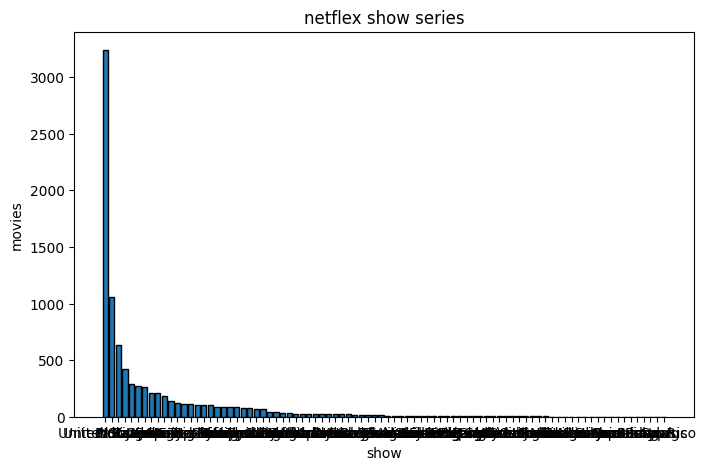

In [ ]:
type_no=df['country'].value_counts()
print(type_no)
plt.figure(figsize=(8,5))
plt.bar(type_no.index, type_no.values, edgecolor='k')
plt.title('netflex show series')
plt.xlabel('show')
plt.ylabel('movies')
plt.show()

In [ ]:
#📊 Insight: The dataset shows that a few countries contribute most of the Netflix content, with one country (like the United States) dominating, while others have significantly lower contributions.

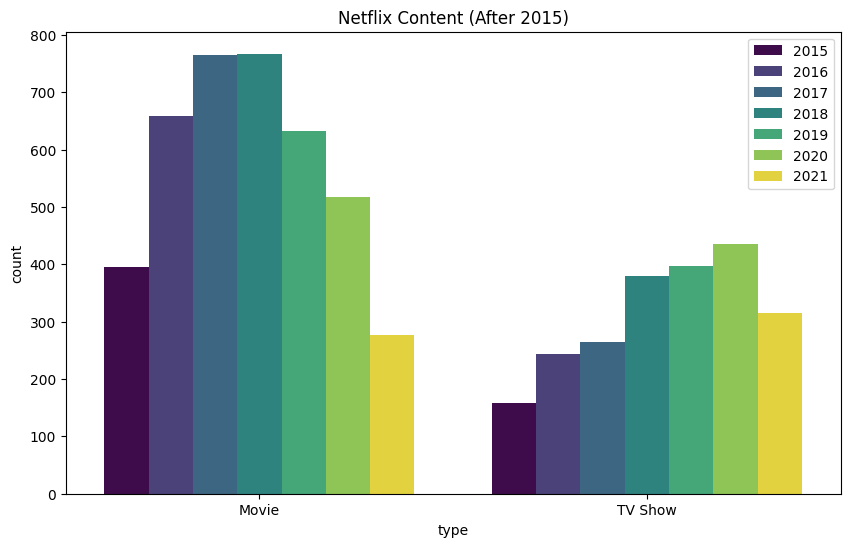

In [ ]:
df_recent = df[df['release_year'] >= 2015]

plt.figure(figsize=(10,6))
sns.countplot(x='type', hue='release_year', data=df_recent, palette='viridis')
plt.legend(bbox_to_anchor=(1,1))
plt.title('Netflix Content (After 2015)')
plt.show()

In [ ]:
#📊 Insight: Netflix content has increased significantly over the years, with movies consistently higher than TV shows.

In [ ]:
movie=df[df['type'] == 'movie']
movie=df['type'].value_counts()

In [ ]:
tv_show=df[df['type'] == 'tv_show']
tv_show=df['type'].value_counts()

In [ ]:
movie=df[df['type'] =='Movie']
movie=movie.groupby('rating')['release_year'].mean()
tv_show=df[df['type'] =='Tv Show']
tv_show=tv_show.groupby('rating')['release_year'].mean()

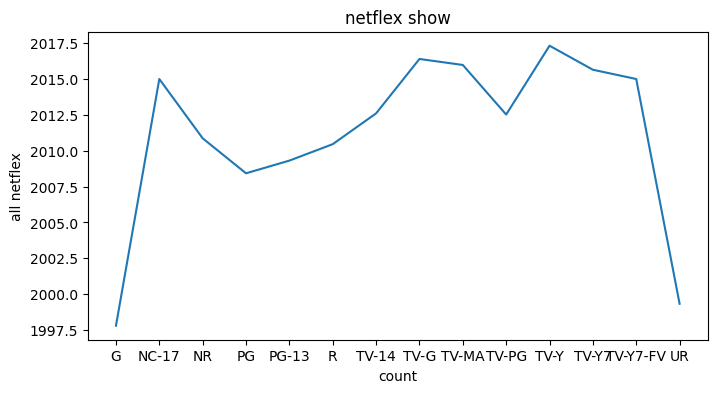

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(movie.index,movie.values,label='Movie')
plt.plot(tv_show.index,tv_show.values,label='Tv Show')
plt.title('netflex show')
plt.xlabel('rating')
plt.ylabel('average release year')
plt.show()



In [ ]:
#📊 Insight: Movies and TV Shows show different trends in average release years across ratings, suggesting that Netflix strategically releases content for various audience groups over time.

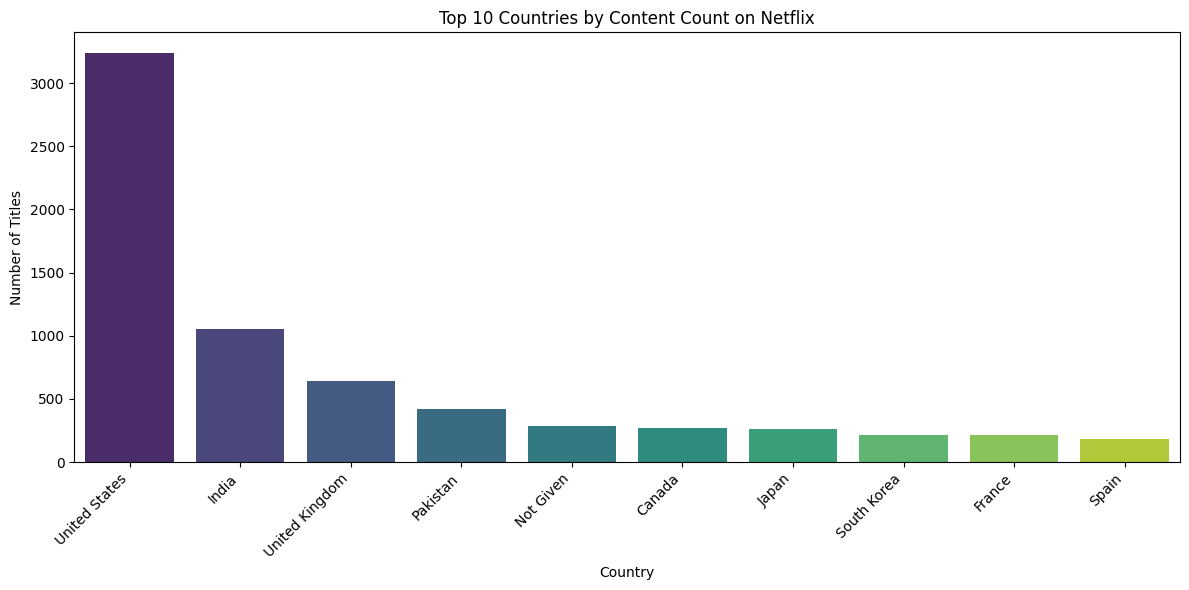

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='country', data=df, order=df['country'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Countries by Content Count on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#📊 Insight: Movies and TV Shows show variation in average release years across ratings, indicating that Netflix strategically produces content for different audience categories over time.

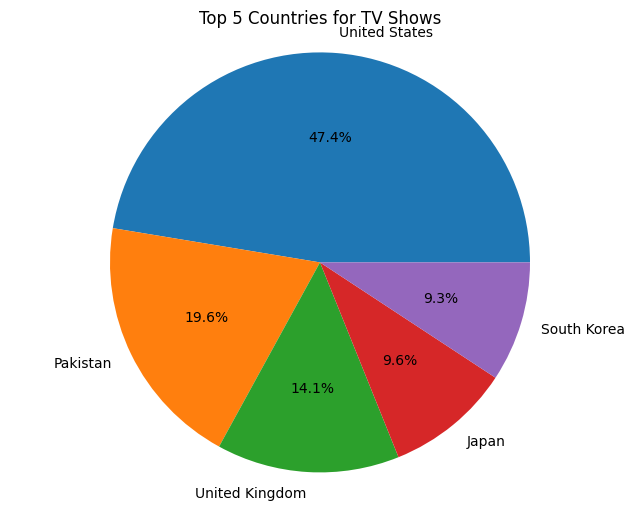

In [ ]:
type_counts = df[df['type'] == 'TV Show'] # Corrected comparison and capitalization
count = type_counts['country'].value_counts().head(5)
plt.figure(figsize=(8,6)) # Increased figure size for better readability
plt.pie(count, labels=count.index, autopct='%1.1f%%') # Corrected arguments: count for values, labels for count.index, and typo autopct
plt.title('Top 5 Countries for TV Shows') # Corrected title
plt.axis('equal')
plt.show()

In [ ]:
#📊 Insight: TV Show production on Netflix is concentrated in a few countries, with the top 5 countries contributing a significant share, highlighting regional dominance in content creation.

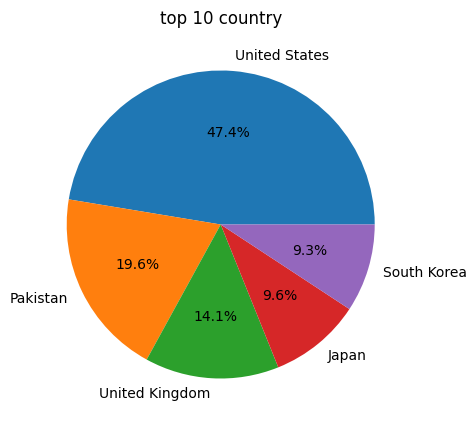

In [ ]:
count=df[df['type']=='TV Show']
ten_country=count['country'].value_counts().head(5)
plt.figure(figsize=(8,5))
plt.pie(ten_country,labels=ten_country.index,autopct='%1.1f%%')
plt.title('top 5 country')
plt.show()

In [ ]:
#📊 Insight: TV Show content on Netflix is heavily dominated by a few countries, with the top 5 contributing the majority share, highlighting regional concentration in production.

### **INSIGHTS**

- Movies dominate Netflix content compared to TV Shows  
- United States is the leading content producer  
- Content growth increased rapidly after 2015  
- Majority of content is rated TV-MA (mature audience)  
- Netflix is expanding globally with diverse content

**CONCLUSION**


Netflix shows strong growth in content over the years, with a major focus on movies and mature audiences. The platform is expanding globally, making it a leading player in the digital entertainment industry.